# EDA 1 — Raw data (before extraction)

**Wolf Day · Track B.** 1,000 synthetic workshop cases (`Dataset/kit/dataset/`). This notebook covers everything that can be analyzed **without any LLM**: structure, missing data, vehicles, timing, note shape, workshop statuses, orders/tasks — plus the `ground_truth` label distributions (scoring labels).

**Deliberately NOT here**: the fine-grained damage analysis (zones × kinds, severity, co-occurrence). That runs on **our DeepSeek extraction** (see `EDA 2 - Extraction.ipynb`) — ground truth only scores it, never replaces it.

Color convention: **blue = whole corpus**, **orange = damage subset**, gradient = ordinal.

## Glossary — the German domain terms you will meet

| German | English |
|---|---|
| Freitext / Werkstattnotiz | free-text workshop note (the challenge input) |
| Schadenfall / Servicefall | damage case / service case |
| Parkschaden · Rangierschaden · Auffahrunfall | parking damage · maneuvering damage · rear-end collision |
| Hagelschaden · Steinschlag · Vandalismus · Wildunfall | hail damage · stone chip · vandalism · wildlife collision |
| Inspektion · Ölwechsel · HU/AU (TÜV) · Räder und Reifen · Bremsen | inspection · oil change · roadworthiness test · wheels & tyres · brakes |
| Stoßstange vorne/hinten · Kotflügel · Tür · Schweller | front/rear bumper · fender · door · sill |
| Motorhaube · Heckklappe · Dach · Windschutzscheibe · Außenspiegel | bonnet · tailgate · roof · windscreen · side mirror |
| leicht · mittel · schwer | light · medium · severe |
| Teilkasko (TK) · Vollkasko (VK) · gegnerische Haftpflicht · Selbstzahler · gesteuert | partial cover · full comprehensive · other party's liability · self-payer · steered claim |
| KVA / KV · SB · Fzg. · KD · Leihwagen | cost estimate · deductible · vehicle · customer · loan car |
| neu · laufend · fertig · abgeschlossen · storniert | new · in progress · ready for pickup · closed · cancelled |

In [1]:
import json, re, collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path(r"C:\Users\benda\Desktop\Hackathon\Dataset\kit\dataset")
TR = json.load(open(r"C:\Users\benda\Desktop\Hackathon\Data\frontend\public\data\translations_en.json", encoding="utf-8"))
TODAY = pd.Timestamp("2026-09-18")

BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#6b6b66"
SEQ_ORANGE = ["#f6c3ad", "#f0925f", "#eb6834"]
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e6e3", "grid.linewidth": .8,
    "axes.axisbelow": True, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.titlelocation": "left",
    "text.color": "#1a1a19", "axes.labelcolor": "#4a4a46",
    "xtick.color": "#6b6b66", "ytick.color": "#6b6b66",
})
def bar_labels(ax, fmt="%d", pad=2):
    for c in ax.containers: ax.bar_label(c, fmt=fmt, padding=pad, fontsize=9, color="#4a4a46")

EN_KIND = {"Parkschaden": "Parking damage", "Rangierschaden": "Maneuvering damage",
    "Auffahrunfall": "Rear-end collision", "Hagelschaden": "Hail damage", "Steinschlag": "Stone chip",
    "Vandalismus": "Vandalism", "Wildunfall": "Wildlife collision", "Inspektion": "Inspection",
    "Ölwechsel": "Oil change", "HU/AU": "Roadworthiness test", "Räder und Reifen": "Wheels & tyres", "Bremsen": "Brakes"}
EN_SEV = {"leicht": "light", "mittel": "medium", "schwer": "severe"}
EN_INS = {"teilkasko": "partial cover (TK)", "vollkasko": "full comprehensive (VK)",
    "haftpflicht_gegner": "other party's liability", "selbstzahler": "self-payer", "gesteuert": "steered claim"}
EN_LC = {"neu": "new", "laufend": "in progress", "fertig": "ready for pickup", "abgeschlossen": "closed", "storniert": "cancelled"}
EN_ZONE_WORDS = {"Stoßstange": "bumper", "Kotflügel": "fender", "Fahrertür": "driver door",
    "Beifahrertür": "passenger door", "Tür": "door", "Schweller": "sill", "Außenspiegel": "mirror",
    "Motorhaube": "bonnet", "Heckklappe": "tailgate", "Dach": "roof", "Windschutzscheibe": "windscreen",
    "vorne": "front", "hinten": "rear", "links": "left", "rechts": "right"}
def zone_en(z):
    w = [EN_ZONE_WORDS.get(x, x) for x in z.split()]
    if len(w) > 1 and w[1] in ("front", "rear"): w[0], w[1] = w[1], w[0]
    return " ".join(w)
def status_en(s): return TR["status"].get(s, s)

pd.set_option("display.max_colwidth", 90)
print("libs OK — pandas", pd.__version__)

libs OK — pandas 3.0.6


In [2]:
cases = json.load(open(DATA / "da-cases.json", encoding="utf-8"))

SCALARS = ["id","external_ref","application_id","created_at","updated_at","canceled_at",
           "in_open_list","completion_date_time","reparation_start_date_time","reparation_end_date_time",
           "license_plate","vehicle_identification_number","manufacturer","model","model_type",
           "first_registration","mileage","company","salutation_id","first_name","last_name",
           "street","zip_code","city","email","phone","customer_number","freitext"]
df = pd.DataFrame([{k: c[k] for k in SCALARS} for c in cases])
df["n_states"] = [len(c["states"]) for c in cases]
df["n_orders"] = [len(c["orders"]) for c in cases]
df["n_tasks"]  = [len(c["workshop_tasks"]) for c in cases]
df["note_len"] = df["freitext"].str.len()
df["has_followups"] = df["freitext"].str.contains("~~~")
for k in ["case_type","case_kind","severity","insurance_type","lifecycle_stage"]:
    df["gt_" + k] = [c["ground_truth"][k] for c in cases]
df["gt_zones"] = [c["ground_truth"]["zones"] for c in cases]
for col in ["created_at","updated_at","canceled_at","reparation_start_date_time","reparation_end_date_time"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")
df["first_registration"] = pd.to_datetime(df["first_registration"], errors="coerce")

print(f"{len(df)} cases × {df.shape[1]} columns (28 raw + derived)")
df.head(3)[["id","manufacturer","model","mileage","gt_case_kind","gt_severity","note_len","n_states","n_orders"]]

1000 cases × 39 columns (28 raw + derived)


,id,manufacturer,model,mileage,gt_case_kind,gt_severity,note_len,n_states,n_orders
0,852719,VW,Tiguan,229651,Inspektion,NaN,205,3,3
1,897113,VW,Golf,287999,Räder und Reifen,NaN,237,3,0
2,847039,Ford,Fiesta,269227,HU/AU,NaN,315,3,1


## One full case, to fix ideas
A multi-zone vandalism case — the free-text note (German = the data itself) plus its control labels.

In [3]:
c = next(c for c in cases if c["id"] == 834726)
print(f"#{c['id']} — {c['manufacturer']} {c['model']}, {c['mileage']} km, plate {c['license_plate']}")
print("Statuses:", " | ".join(f"{s['name']}  [{status_en(s['name'])}]" for s in c["states"]))
print("-" * 80); print(c["freitext"]); print("-" * 80)
print("GROUND TRUTH:", json.dumps(c["ground_truth"], ensure_ascii=False))

#834726 — Ford Kuga, 86994 km, plate QQN-JC 1499
Statuses: 🙂Vorgang angelegt  [🙂Case created] | Vermessen und Kalibrieren  [Measure and calibrate] | Lack Neu  [Paint new] | 🛠📢 Reparaturtermin vereinbaren  [🛠📢Schedule repair appointment]
--------------------------------------------------------------------------------
Kunde meldet: Vandalismus, Schaden am 04.05. entdeckt. Kotflügel hinten rechts: Kratzer im Klarlack, ca. 5 cm.
Fahrertür ebenfalls: feine Kratzspuren.
Auch Kotflügel vorne rechts beschädigt (Kratzer im Klarlack).
Kunde möchte Fzg. bis Monatsende zurück. Kunde wartet vor Ort.
Vollkasko, SB 500 EUR, Schadenmeldung raus.
Nach Zerlegung nachkalkulieren.
~~~~~~~~~~~~~
11.05.26 16:28 Servicebüro: Kalkulation fertig, an Prüfer
18.05.26 19:28 A. Thiel: Freigabe Versicherung eingetroffen
19.05.26 22:28 A. Thiel: KD informiert, Termin steht
--------------------------------------------------------------------------------
GROUND TRUTH: {"case_type": "damage", "case_kind": "Vandalismus"

## Missing data
Trap #1 in this dataset: missing values come in **two shapes** (`null` AND empty string `""`), and you must separate **structural** missing (expected: empty `canceled_at` = not cancelled, empty `gt_severity` = service case with no damage) from **data-quality** missing (real input gaps: email, salutation, first/last name).

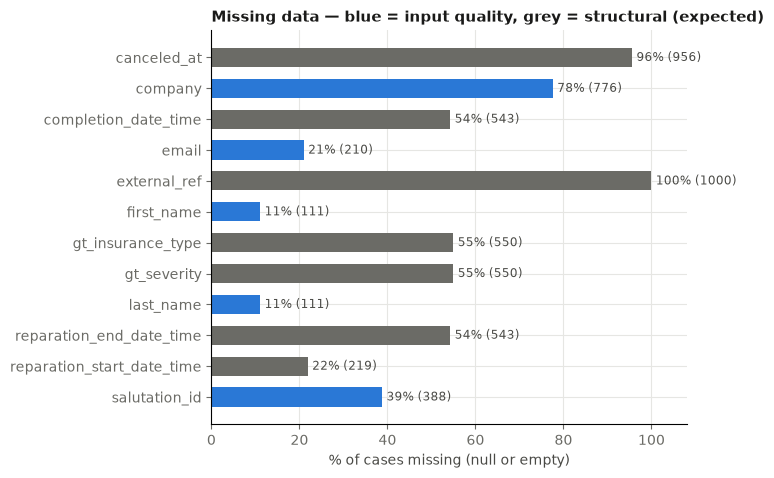

,missing,%,as_null,as_empty
canceled_at,956,95.6,956,0
company,776,77.6,0,776
completion_date_time,543,54.3,543,0
email,210,21.0,210,0
external_ref,1000,100.0,1000,0
first_name,111,11.1,0,111
gt_insurance_type,550,55.0,550,0
gt_severity,550,55.0,550,0
last_name,111,11.1,0,111
reparation_end_date_time,543,54.3,543,0


In [4]:
def missing_table(frame):
    isna = frame.isna()
    empty = frame.map(lambda v: isinstance(v, str) and v.strip() == "")
    m = (isna | empty).sum().sort_values(ascending=False)
    t = pd.DataFrame({"missing": m, "%": (100 * m / len(frame)).round(1),
                      "as_null": isna.sum(), "as_empty": empty.sum()})
    return t[t["missing"] > 0]

STRUCTURAL = {"canceled_at","reparation_start_date_time","reparation_end_date_time",
              "completion_date_time","external_ref","gt_severity","gt_insurance_type"}
miss = missing_table(df.drop(columns=["gt_zones"]))

def plot_missing(t, structural=STRUCTURAL):
    fig, ax = plt.subplots(figsize=(7.5, .34 * len(t) + .8))
    colors = [GREY if c in structural else BLUE for c in t.index]
    ax.barh(t.index[::-1], t["%"][::-1], color=colors[::-1], height=.62)
    for y, (pct, n) in enumerate(zip(t["%"][::-1], t["missing"][::-1])):
        ax.text(pct + 1, y, f"{pct:.0f}% ({n})", va="center", fontsize=8.5, color="#4a4a46")
    ax.set_xlim(0, 108); ax.set_xlabel("% of cases missing (null or empty)")
    ax.set_title("Missing data — blue = input quality, grey = structural (expected)")
    plt.tight_layout(); plt.show()

plot_missing(miss)
miss

**Reading.** The grey bars are healthy: `external_ref` almost never set, `canceled_at` filled only for the 44 cancelled cases, repair dates set only once repair started/finished, `gt_severity`/`gt_insurance_type` filled only for the 450 damage cases. The blue bars are the true face of the source system: **~1 in 5 emails missing, ~39% without salutation**, sometimes empty first/last names, and `company` empty meaning "private customer" (implicit encoding!).

⚠️ **`canceled_at` semantics** (verified by crosstab): set ⟺ case `storniert`/cancelled (44/44, no exception). An empty `canceled_at` says **only** "not cancelled" — it does NOT say whether the case is done or running. That lives in `in_open_list`: `True` ⟺ {new, in progress, ready for pickup} (668 cases), `False` ⟺ {closed, cancelled} (332).

→ For the pipeline: read `company == ""` as "private customer", never impute these fields, and parse the CSV with a real parser (`freitext` contains newlines) — or work from the JSON as we do.

## The vehicle fleet

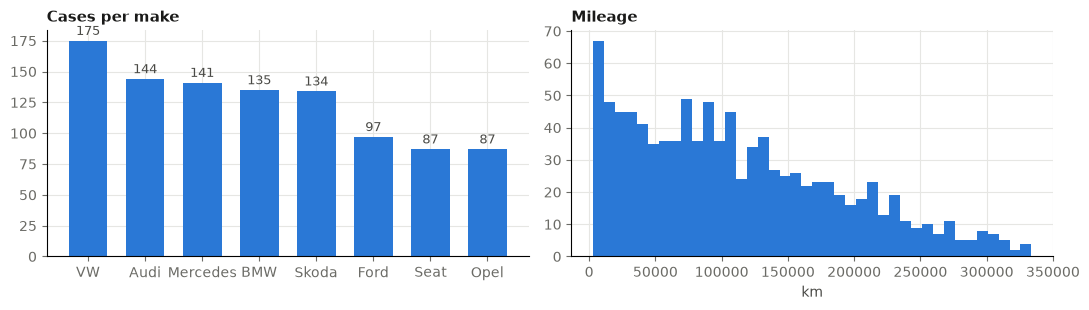

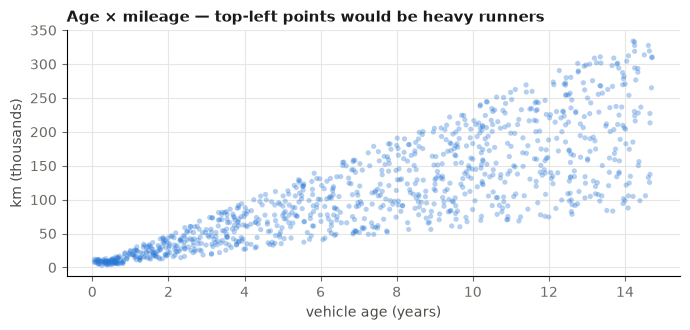

First registrations: 2012-01-01 → 2026-08-28
0 vehicle(s) above 40,000 km/year → no mileage outliers: the age↔km generation is consistent


,id,manufacturer,model,mileage,age_years,km_per_year
760,880199,Skoda,Karoq,30309,1.2,25925.9
745,882891,Audi,A6 Avant,12767,0.4,25534.0
252,897638,VW,T6.1 Transporter,15648,0.6,25289.5
918,838742,Audi,Q2,34007,1.3,25246.1
127,878238,Mercedes,A-Klasse,21690,0.9,24991.4


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
mk = df["manufacturer"].value_counts()
axes[0].bar(mk.index, mk.values, color=BLUE, width=.68)
axes[0].set_title("Cases per make"); bar_labels(axes[0])
axes[1].hist(df["mileage"], bins=40, color=BLUE)
axes[1].set_title("Mileage"); axes[1].set_xlabel("km")
plt.tight_layout(); plt.show()

df["age_years"] = (TODAY - df["first_registration"]).dt.days / 365.25
df["km_per_year"] = df["mileage"] / df["age_years"].clip(lower=0.5)
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.scatter(df["age_years"], df["mileage"] / 1000, s=14, color=BLUE, alpha=.35, edgecolors="none")
ax.set_xlabel("vehicle age (years)"); ax.set_ylabel("km (thousands)")
ax.set_title("Age × mileage — top-left points would be heavy runners")
plt.tight_layout(); plt.show()

print("First registrations:", df["first_registration"].min().date(), "→", df["first_registration"].max().date())
sus = df[df["km_per_year"] > 40_000]
print(f"{len(sus)} vehicle(s) above 40,000 km/year → " +
      ("inspect (fleet/taxi or generator artifact)" if len(sus) else "no mileage outliers: the age↔km generation is consistent"))
top_roll = df.sort_values("km_per_year", ascending=False).head(5)[["id","manufacturer","model","mileage","age_years","km_per_year"]].copy()
top_roll[["age_years","km_per_year"]] = top_roll[["age_years","km_per_year"]].round(1)
top_roll  # top five heaviest runners, for the eye

## Case timing

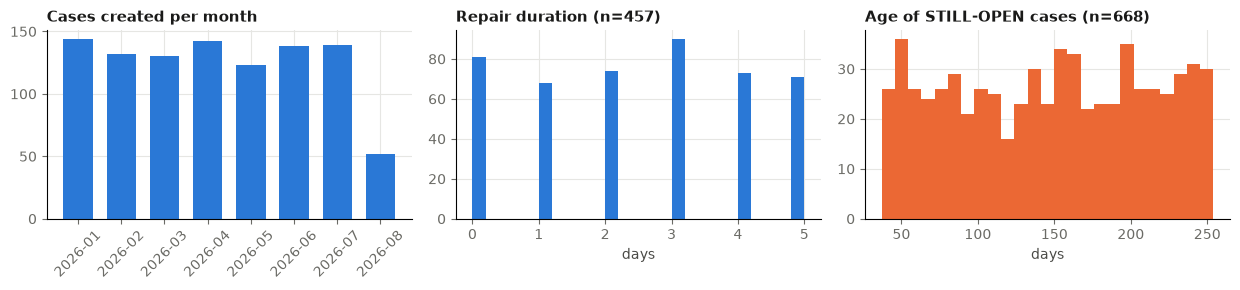

Open: 668 | Cancelled: 44 | Median repair duration: 3 d | Median age of open cases: 150 d


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3))
pm = df["created_at"].dt.to_period("M").value_counts().sort_index()
axes[0].bar(pm.index.astype(str), pm.values, color=BLUE, width=.68)
axes[0].set_title("Cases created per month"); axes[0].tick_params(axis="x", rotation=45)
dur = (df["reparation_end_date_time"] - df["reparation_start_date_time"]).dt.days.dropna()
axes[1].hist(dur, bins=25, color=BLUE)
axes[1].set_title(f"Repair duration (n={len(dur)})"); axes[1].set_xlabel("days")
open_age = (TODAY - df.loc[df["in_open_list"], "created_at"]).dt.days
axes[2].hist(open_age, bins=25, color=ORANGE)
axes[2].set_title(f"Age of STILL-OPEN cases (n={len(open_age)})"); axes[2].set_xlabel("days")
plt.tight_layout(); plt.show()
print(f"Open: {df['in_open_list'].sum()} | Cancelled: {df['canceled_at'].notna().sum()} | "
      f"Median repair duration: {dur.median():.0f} d | Median age of open cases: {open_age.median():.0f} d")

## The notes — the raw material of the challenge
We don't *understand* them yet (that's the LLM's job), we measure their **shape**: length, the dated `~~~` follow-up block, recurring template sentences (the synthetic generator's fingerprint), trade abbreviations.

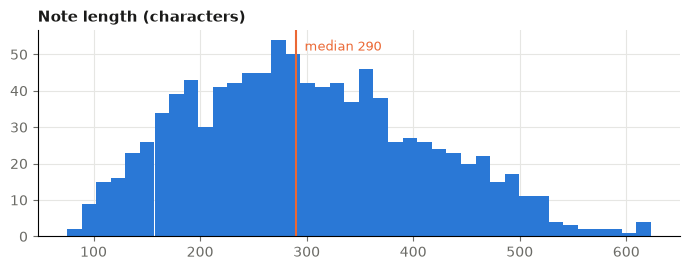

Notes with a '~~~' follow-up block: 688 / 1000

Top template sentences (verbatim German = the data · English gloss):
   61×  Fotos liegen im Vorgang.  [photos are on file]
   60×  Bitte Wiedervorlage in einer Woche.  [resubmit in one week]
   59×  Termin nach Teileeingang.  [appointment once parts arrive]
   59×  Kunde ist informiert, meldet sich.  [customer informed, will get in touch]
   58×  Termin steht, Dauer ca. 2 Tage.  [appointment set, ~2 days]
   58×  Fzg. steht auf dem Hof.  [vehicle is in the yard]
   57×  Teile bestellt, Liefertermin offen.  [parts ordered, delivery date open]
   51×  Kunde bekommt Zwischeninfo.  [customer gets interim update]
   50×  Ersatzteil im Rückstand, Kunde informiert.  [spare part backordered, customer informed]
   47×  Zusätzlich Klappern vorne rechts bei Bodenwellen.  [additionally, rattling front right on bumps]


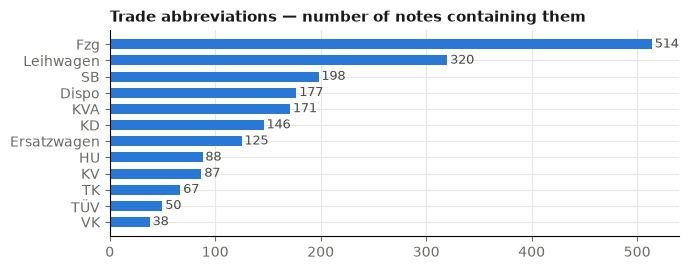

In [7]:
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.hist(df["note_len"], bins=40, color=BLUE)
ax.axvline(df["note_len"].median(), color=ORANGE, lw=1.5)
ax.text(df["note_len"].median() + 8, ax.get_ylim()[1] * .9, f"median {df['note_len'].median():.0f}", color=ORANGE, fontsize=9)
ax.set_title("Note length (characters)"); plt.tight_layout(); plt.show()
print(f"Notes with a '~~~' follow-up block: {df['has_followups'].sum()} / 1000")

GLOSS = {"Fotos liegen im Vorgang.": "photos are on file",
    "Bitte Wiedervorlage in einer Woche.": "resubmit in one week",
    "Termin nach Teileeingang.": "appointment once parts arrive",
    "Kunde ist informiert, meldet sich.": "customer informed, will get in touch",
    "Termin steht, Dauer ca. 2 Tage.": "appointment set, ~2 days",
    "Fzg. steht auf dem Hof.": "vehicle is in the yard",
    "Teile bestellt, Liefertermin offen.": "parts ordered, delivery date open",
    "Kunde bekommt Zwischeninfo.": "customer gets interim update",
    "Ersatzteil im Rückstand, Kunde informiert.": "spare part backordered, customer informed",
    "Zusätzlich Klappern vorne rechts bei Bodenwellen.": "additionally, rattling front right on bumps"}
body_lines = collections.Counter()
for t in df["freitext"]:
    for ln in t.split("~~~")[0].split("\n"):
        if len(ln.strip()) > 15: body_lines[ln.strip()] += 1
print("\nTop template sentences (verbatim German = the data · English gloss):")
for ln, n in body_lines.most_common(10): print(f"  {n:3d}×  {ln}  [{GLOSS.get(ln, TR['snippets'].get(ln, ''))}]")

abbr = ["KVA","KV ","SB ","Fzg","TK","VK","HU","TÜV","KD ","Dispo","Leihwagen","Ersatzwagen"]
counts = {a.strip(): df["freitext"].str.contains(re.escape(a)).sum() for a in abbr}
fig, ax = plt.subplots(figsize=(7, 2.8))
s = pd.Series(counts).sort_values()
ax.barh(s.index, s.values, color=BLUE, height=.62); bar_labels(ax)
ax.set_title("Trade abbreviations — number of notes containing them"); plt.tight_layout(); plt.show()

## Workshop statuses (already structured → no LLM extraction needed)
213 statuses, 8 categories, emoji from the live system. The first status of each case = the general case status. Shown here with their English translation (DeepSeek-translated once, cached).

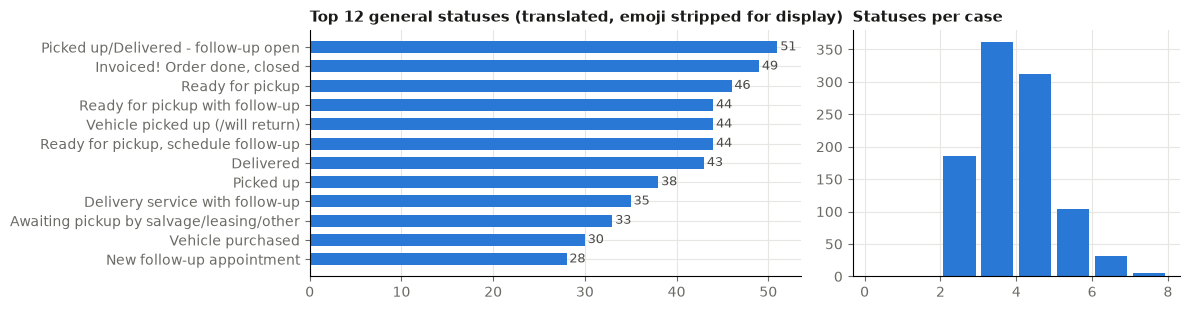

Status mentions per category: {'case status': 1000, 'mechanical workshop': 550, 'parts': 453, 'body shop': 450, 'parts service': 358, 'appointments': 278, 'paint shop': 277, 'claims-handler tasks': 81}


In [8]:
def deemoji(s):
    s = "".join(ch for ch in s if ord(ch) < 0x2190)
    return re.sub(r"\s{2,}", " ", s).strip(" !")
first_state = pd.Series([c["states"][0]["name"] if c["states"] else "(none)" for c in cases])
top = first_state.value_counts().head(12).rename(lambda s: deemoji(status_en(s)))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.2), width_ratios=[3, 2])
axes[0].barh(top.index[::-1], top.values[::-1], color=BLUE, height=.62)
bar_labels(axes[0]); axes[0].set_title("Top 12 general statuses (translated, emoji stripped for display)")
axes[1].hist(df["n_states"], bins=range(0, df["n_states"].max() + 2), color=BLUE, rwidth=.85)
axes[1].set_title("Statuses per case")
plt.tight_layout(); plt.show()
CAT_EN = {"Vorgangsstatus": "case status", "3.1.0 Werkstattstatus Mech.": "mechanical workshop",
          "🛒🔨Teile Status": "parts", "2.1.0 Karosserie Status": "body shop", "4.0.0 Teiledienst": "parts service",
          "📅Terminstatus": "appointments", "2.3.0 Lack Status": "paint shop", "8.1.0 Aufgaben Schadensteuerer": "claims-handler tasks"}
cats = collections.Counter(s["category"] for c in cases for s in c["states"])
print("Status mentions per category:", {CAT_EN.get(k, k): v for k, v in sorted(cats.items(), key=lambda kv: -kv[1])})

## Orders & workshop tasks (the commercial/planning side)

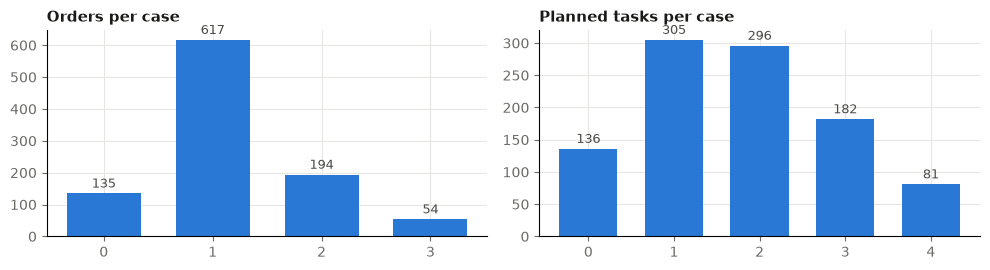

1167 orders in total, 391 of them linked to an insurer — consistent with the 450 damage cases


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 2.8))
for ax, col, title in [(axes[0], "n_orders", "Orders per case"), (axes[1], "n_tasks", "Planned tasks per case")]:
    vc = df[col].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color=BLUE, width=.68); bar_labels(ax); ax.set_title(title)
plt.tight_layout(); plt.show()
with_insurer = sum(1 for c in cases for o in c["orders"] if o["insurer_id"])
total_orders = sum(len(c["orders"]) for c in cases)
print(f"{total_orders} orders in total, {with_insurer} of them linked to an insurer — consistent with the 450 damage cases")

## Ground truth — control-label distributions
⚠️ **Usage contract**: these labels exist to **score** our extraction, not to feed the analysis ("Reading it instead of the free text defeats the exercise"). We look at them here only to know the terrain — and severity will be **inferred by DeepSeek** from the note wording (it is never written: 0/1000 notes contain light/medium/severe words).

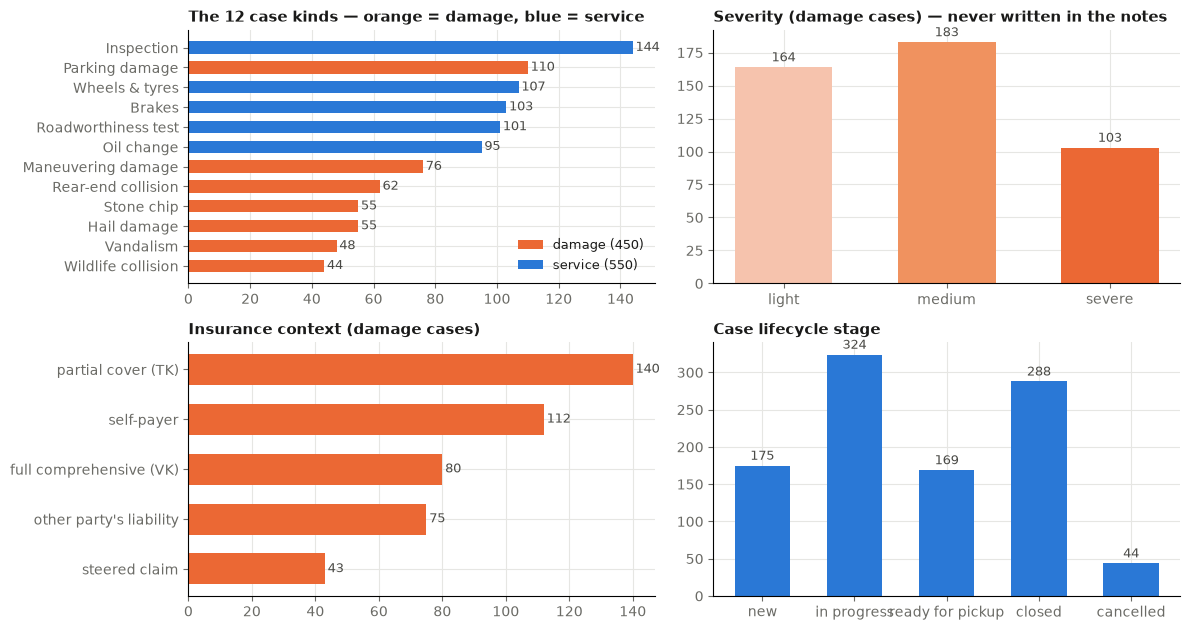

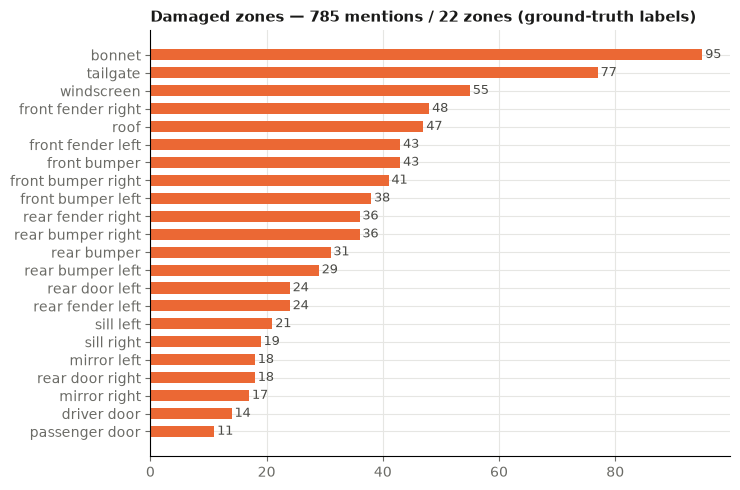

Multi-zone cases: 254 / 450 damage cases


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6.4))
kinds = df.groupby(["gt_case_kind", "gt_case_type"]).size().reset_index(name="n").sort_values("n")
colors = [ORANGE if t == "damage" else BLUE for t in kinds["gt_case_type"]]
axes[0,0].barh(kinds["gt_case_kind"].map(EN_KIND), kinds["n"], color=colors, height=.62)
bar_labels(axes[0,0]); axes[0,0].set_title("The 12 case kinds — orange = damage, blue = service")
axes[0,0].legend(handles=[plt.Rectangle((0,0),1,1,fc=ORANGE), plt.Rectangle((0,0),1,1,fc=BLUE)],
                 labels=["damage (450)", "service (550)"], frameon=False, fontsize=9, loc="lower right")

sev = df["gt_severity"].value_counts().reindex(["leicht", "mittel", "schwer"])
axes[0,1].bar([EN_SEV[s] for s in sev.index], sev.values, color=SEQ_ORANGE, width=.6); bar_labels(axes[0,1])
axes[0,1].set_title("Severity (damage cases) — never written in the notes")

ins = df["gt_insurance_type"].value_counts()
axes[1,0].barh([EN_INS[i] for i in ins.index[::-1]], ins.values[::-1], color=ORANGE, height=.62); bar_labels(axes[1,0])
axes[1,0].set_title("Insurance context (damage cases)")

lc = df["gt_lifecycle_stage"].value_counts().reindex(["neu", "laufend", "fertig", "abgeschlossen", "storniert"])
axes[1,1].bar([EN_LC[s] for s in lc.index], lc.values, color=BLUE, width=.6); bar_labels(axes[1,1])
axes[1,1].set_title("Case lifecycle stage")
plt.tight_layout(); plt.show()

zones = collections.Counter(z for zz in df["gt_zones"] for z in zz)
zs = pd.Series(zones).sort_values().rename(zone_en)
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.barh(zs.index, zs.values, color=ORANGE, height=.62); bar_labels(ax)
ax.set_title(f"Damaged zones — {sum(zones.values())} mentions / {len(zones)} zones (ground-truth labels)")
plt.tight_layout(); plt.show()
multi = (df["gt_zones"].str.len() > 1).sum()
print(f"Multi-zone cases: {multi} / 450 damage cases")

## Recap — outliers and traps found

| # | Finding | Pipeline consequence |
|---|---|---|
| 1 | Missing in two shapes (`null` **and** `""`), `company:""` = private customer | normalize at ingestion, never impute |
| 2 | Multi-line `freitext` inside the CSV | always a real CSV parser (or work from the JSON — our choice) |
| 3 | No vehicle above 40,000 km/year | plausible fleet — nothing to fix |
| 4 | Template sentences repeated 47–61× | synthetic-generator fingerprint — say it openly at the fireside, no pipeline impact |
| 5 | Emoji in statuses, fonts without glyphs | strip for display, keep raw in data |
| 6 | GT zones appear verbatim, but `Stoßstange vorne` ⊂ `Stoßstange vorne links` | baseline matching with word boundaries + longest-first |
| 7 | Severity never literal | **DeepSeek inference**, scored against `gt_severity` |

**Next**: the extraction pipeline — schema v1.1 + `extract.py` (DeepSeek, per-case cache, backoff) + 20-case pilot scored against GT → full 1,000 batch → `EDA 2` on our extractions.